# Assignment 1 — Numerical Modelling (Python)


**Function**: \( f(x)=\sin x \), **exact derivative**: \( f'(x)=\cos x \)

This notebook provides:
1. Finite differences at selected points (manual + code); compare errors.
2. Error vs. step-size (log–log) to check convergence orders.
3. Full domain \((0,2\pi)\): discretize, compute derivatives (F/B/C), compare with exact; report error stats.
4. Newton–Raphson roots of \(\sin x\) on \((0,4\pi)\) using exact and finite-difference derivatives.

TODO Task for the Students:

Write the code in the cell wherever TODO is mentioned and run the code to check the results and verify by the TAs.

In [4]:
# -------------------------
# Required Libraries
# -------------------------
import math, numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# -------------------------
# Editable parameters
# -------------------------
X_POINTS = [math.pi/4, math.pi/2, math.pi]
H_VALUES = [1e-1, 5e-2, 2e-2, 1e-2, 5e-3, 2e-3, 1e-3]   # step sizes for convergence study
H_DOMAIN = 0.02     # step for domain (0, 2π);
INITIAL_GUESSES = [0.1, 1.0, 3.0, 5.0, 7.0, 10.0, 12.0]  # in (0, 4π)
H_NEWTON = 1e-4     # step used by FD-Newton;

def f(x): return math.sin(x)
def df_exact(x): return math.cos(x)
def d_forward(f, x, h):  return (f(x + h) - f(x)) / h
def d_backward(f, x, h): return (f(x) - f(x - h)) / h
def d_central(f, x, h):  return (f(x + h) - f(x - h)) / (2 * h)

def abs_err(approx, exact): return abs(approx - exact)

def evaluate_at_points(points, h):
    rows = []
    for x in points:
        exact = df_exact(x)
        fwd = d_forward(f, x, h)
        bwd = d_backward(f, x, h)
        cen = d_central(f, x, h)
        rows.append({
            "x": x, "h": h, "exact": exact,
            "forward": fwd, "err_forward": abs_err(fwd, exact),
            "backward": bwd, "err_backward": abs_err(bwd, exact),
            "central": cen, "err_central": abs_err(cen, exact),
        })
    return rows

def convergence_study(points, h_values):
    hs, ef, eb, ec = [], [], [], []
    for h in h_values:
        batch = evaluate_at_points(points, h)
        ef.append(np.mean([r["err_forward"]  for r in batch]))
        eb.append(np.mean([r["err_backward"] for r in batch]))
        ec.append(np.mean([r["err_central"]  for r in batch]))
        hs.append(h)
    return {"h": np.array(hs), "err_forward": np.array(ef),
            "err_backward": np.array(eb), "err_central": np.array(ec)}

def slope_loglog(x, y):
    lx, ly = np.log10(x), np.log10(y)
    m, c = np.polyfit(lx, ly, 1)
    return m, c

## 1) Selected points — compute FD derivatives and errors

In [6]:
# --------------------------------------------------------------
# Tabular representation of the 1st Objective of the Assignment
# --------------------------------------------------------------
h = H_VALUES[3]
rows = evaluate_at_points(X_POINTS, h)
import pandas as pd
df = pd.DataFrame(rows)
df

,x,h,exact,forward,err_forward,backward,err_backward,central,err_central
0,0.785398,0.01,7.071068e-01,0.703559,0.003547,0.710631,0.003524,0.707095,1.178505e-05
1,1.570796,0.01,6.123234e-17,-0.005000,0.005000,0.005000,0.005000,0.000000,6.123234e-17
2,3.141593,0.01,-1.000000e+00,-0.999983,0.000017,-0.999983,0.000017,-0.999983,1.666658e-05


In [5]:
# --------------------------------------------------------------
# Tabular representation of the 2nd Objective of the Assignment
# --------------------------------------------------------------
res = convergence_study(X_POINTS, H_VALUES)
import pandas as pd
df = pd.DataFrame(res)
df

,h,err_forward,err_backward,err_central
0,0.100,0.029376,0.028591,9.479186e-04
1,0.050,0.014460,0.014264,2.370685e-04
2,0.020,0.005728,0.005697,3.793495e-05
3,0.010,0.002855,0.002847,9.483879e-06
4,0.005,0.001425,0.001423,2.370979e-06
5,0.002,0.000569,0.000569,3.793570e-07
6,0.001,0.000285,0.000285,9.483929e-08


## 2) Convergence — error vs. h (log–log)

Estimated orders: forward≈1.01, backward≈1.00, central≈2.00


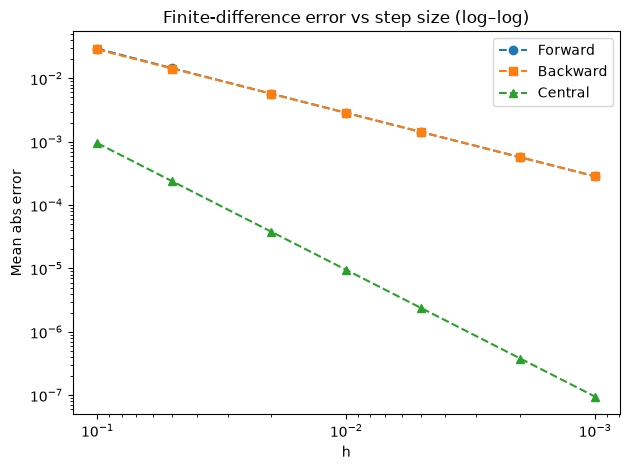

In [6]:
res = convergence_study(X_POINTS, H_VALUES)
m_f, _ = slope_loglog(res["h"], res["err_forward"])
m_b, _ = slope_loglog(res["h"], res["err_backward"])
m_c, _ = slope_loglog(res["h"], res["err_central"])
print(f"Estimated orders: forward≈{m_f:.2f}, backward≈{m_b:.2f}, central≈{m_c:.2f}")

plt.figure()
plt.loglog(res["h"], res["err_forward"], marker="o", linestyle="--", label="Forward")
plt.loglog(res["h"], res["err_backward"], marker="s", linestyle="--", label="Backward")
plt.loglog(res["h"], res["err_central"], marker="^", linestyle="--", label="Central")
plt.gca().invert_xaxis()
plt.xlabel("h"); plt.ylabel("Mean abs error")
plt.title("Finite-difference error vs step size (log–log)")
plt.legend(); plt.tight_layout()
plt.savefig("fd_convergence.jpg", dpi=160)
plt.show()

## 3) Full domain (0, 2π): discretize and compare with exact

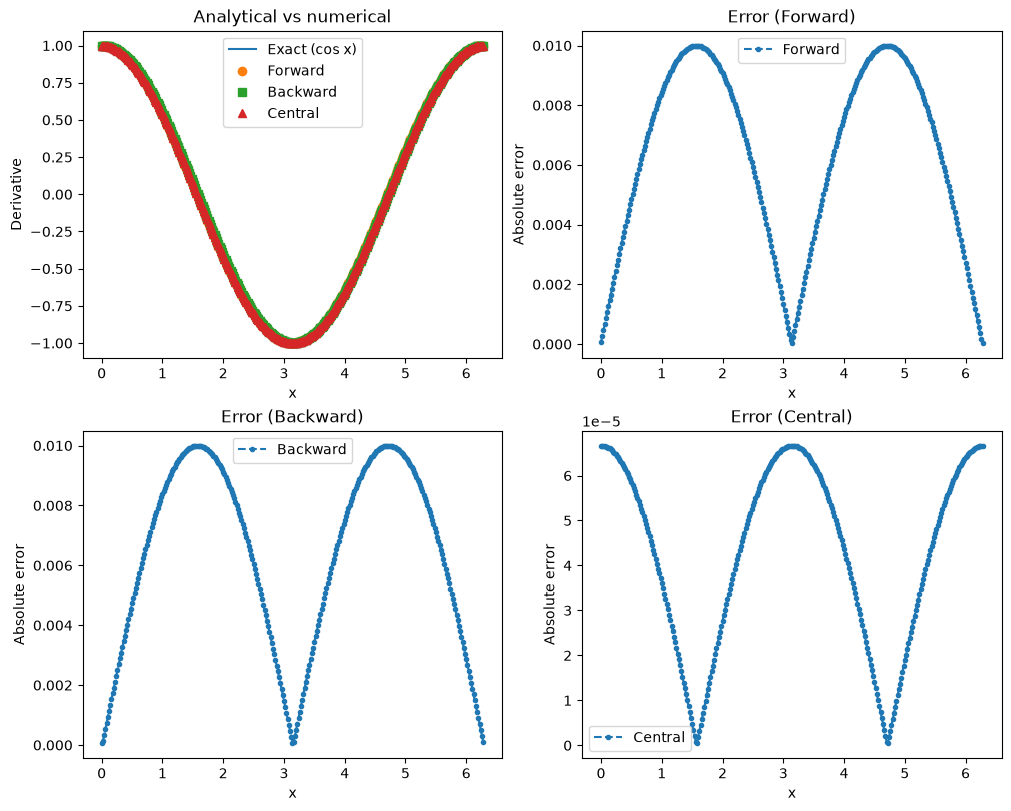

({'max_error': 0.00999980361957837,
  'x_at_max': 1.56,
  'min_error': 3.481303899000032e-05,
  'x_at_min': 6.28},
 {'max_error': 0.009999884430330709,
  'x_at_max': 4.72,
  'min_error': 6.666533334598324e-05,
  'x_at_min': 0.0},
 {'max_error': 6.666533334598324e-05,
  'x_at_max': 0.0,
  'min_error': 5.073862630955786e-07,
  'x_at_min': 4.72})

In [8]:
def grid_over_domain(a, b, h):
    n = int(math.floor((b - a) / h)) + 1
    xs = a + np.arange(n)*h
    xs = xs[xs <= b]
    return xs

def evaluate_on_domain(h):
    a, b = 0.0, 2.0*math.pi
    xs = grid_over_domain(a, b, h)
    fwd = np.zeros_like(xs); bwd = np.zeros_like(xs); cen = np.zeros_like(xs)
    exact = np.cos(xs)
    for i, x in enumerate(xs):
        if i == 0:
            fwd[i] = d_forward(f, x, h); bwd[i] = d_backward(f, x, h); cen[i] = d_central(f, x, h)
        elif i == len(xs)-1:
            fwd[i] = d_forward(f, x, h); bwd[i] = d_backward(f, x, h); cen[i] = d_central(f, x, h)
        else:
            fwd[i] = d_forward(f, x, h); bwd[i] = d_backward(f, x, h); cen[i] = d_central(f, x, h)
    ef = np.abs(fwd - exact); eb = np.abs(bwd - exact); ec = np.abs(cen - exact)
    return xs, exact, fwd, bwd, cen, ef, eb, ec

xs, exact, fwd, bwd, cen, ef, eb, ec = evaluate_on_domain(H_DOMAIN)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# (0,0): curves
ax = axes[0, 0]
ax.plot(xs, exact, label="Exact (cos x)")
ax.plot(xs, fwd, marker="o", linestyle="None", label="Forward")
ax.plot(xs, bwd, marker="s", linestyle="None", label="Backward")
ax.plot(xs, cen, marker="^", linestyle="None", label="Central")
ax.set_xlabel("x"); ax.set_ylabel("Derivative"); ax.set_title("Analytical vs numerical")
ax.legend()

# (0,1): forward error
ax = axes[0, 1]
ax.plot(xs, ef, marker=".", linestyle="--", label="Forward")
ax.set_xlabel("x"); ax.set_ylabel("Absolute error"); ax.set_title("Error (Forward)")
ax.legend()

# (1,0): backward error
ax = axes[1, 0]
ax.plot(xs, eb, marker=".", linestyle="--", label="Backward")
ax.set_xlabel("x"); ax.set_ylabel("Absolute error"); ax.set_title("Error (Backward)")
ax.legend()

# (1,1): central error
ax = axes[1, 1]
ax.plot(xs, ec, marker=".", linestyle="--", label="Central")
ax.set_xlabel("x"); ax.set_ylabel("Absolute error"); ax.set_title("Error (Central)")
ax.legend()

fig.savefig("derivatives_and_errors_grid.jpg", dpi=160)
plt.show()

def summarize_domain_errors(xs, err):
    e = err.copy()
    mask = ~np.isnan(e)
    if not np.any(mask): return None
    e = e[mask]; x = xs[mask]
    i_max = int(np.argmax(e)); i_min = int(np.argmin(e))
    return {"max_error": float(e[i_max]), "x_at_max": float(x[i_max]),
            "min_error": float(e[i_min]), "x_at_min": float(x[i_min])}

sum_f = summarize_domain_errors(xs, ef)
sum_b = summarize_domain_errors(xs, eb)
sum_c = summarize_domain_errors(xs, ec)
sum_f, sum_b, sum_c

## 4) Newton–Raphson roots on (0, 4π) — exact vs FD derivatives

In [18]:
def newton_exact(x0, tol=1e-5, maxiter=100):
    x = float(x0)
    for k in range(maxiter):
        fx = math.sin(x); dfx = math.cos(x)
        if abs(dfx) < 1e-14: return None, k, "derivative ~ 0"
        xnew = x - fx / dfx
        if abs(xnew - x) < tol: return xnew, k+1, "ok"
        x = xnew
    return x, maxiter, "maxiter"

def newton_fd(x0, h, method="central", tol=1e-5, maxiter=100):
    x = float(x0)
    for k in range(maxiter):
        fx = math.sin(x)
        if method == "forward":
            dfx =  d_forward(f, x, h)
        elif method == "backward":
            dfx = d_backward(f, x, h)
        else:
            dfx = d_central(f, x, h)
        if abs(dfx) < 1e-14: return None, k, "derivative ~ 0"
        xnew = x - fx / dfx
        if abs(xnew - x) < tol: return xnew, k+1, "ok"
        x = xnew
    return x, maxiter, "maxiter"

a_nr, b_nr = 0.0, 4.0*math.pi
records = []
for x0 in INITIAL_GUESSES:
    if not (a_nr <= x0 <= b_nr): continue
    root_e, it_e, status_e = newton_exact(x0)
    root_cf, it_cf, status_cf = newton_fd(x0, H_NEWTON, "forward")
    root_cb, it_cb, status_cb = newton_fd(x0, H_NEWTON, "backward")
    root_cc, it_cc, status_cc = newton_fd(x0, H_NEWTON, "central")
    records.append({
        "x0": x0,
        "exact_root": root_e, "exact_iters": it_e, "exact_status": status_e,
        "fd_forward_root": root_cf, "fd_forward_iters": it_cf, "fd_forward_status": status_cf,
        "fd_backward_root": root_cb, "fd_backward_iters": it_cb, "fd_backward_status": status_cb,
        "fd_central_root": root_cc, "fd_central_iters": it_cc, "fd_central_status": status_cc,
    })

pd.DataFrame.from_records(records)

,x0,exact_root,exact_iters,exact_status,fd_forward_root,fd_forward_iters,fd_forward_status,fd_backward_root,fd_backward_iters,fd_backward_status,fd_central_root,fd_central_iters,fd_central_status
0,0.1,0.000000,3,ok,-1.248834e-20,3,ok,-3.096523e-20,3,ok,-2.175472e-20,3,ok
1,1.0,0.000000,5,ok,9.682490e-24,5,ok,-1.505234e-21,5,ok,-7.531574e-22,5,ok
2,3.0,3.141593,3,ok,3.141593e+00,3,ok,3.141593e+00,3,ok,3.141593e+00,3,ok
3,5.0,9.424778,6,ok,9.424778e+00,6,ok,9.424778e+00,6,ok,9.424778e+00,6,ok
4,7.0,6.283185,4,ok,6.283185e+00,4,ok,6.283185e+00,4,ok,6.283185e+00,4,ok
5,10.0,9.424778,4,ok,9.424778e+00,4,ok,9.424778e+00,4,ok,9.424778e+00,4,ok
6,12.0,12.566371,4,ok,1.256637e+01,4,ok,1.256637e+01,4,ok,1.256637e+01,4,ok
